In [1]:
import numpy as  np

In [2]:
import matplotlib.pyplot as plt

In [3]:
hours = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
scores = np.array([35, 45, 50, 55, 65, 70, 75, 82, 88, 95])

Chart saved


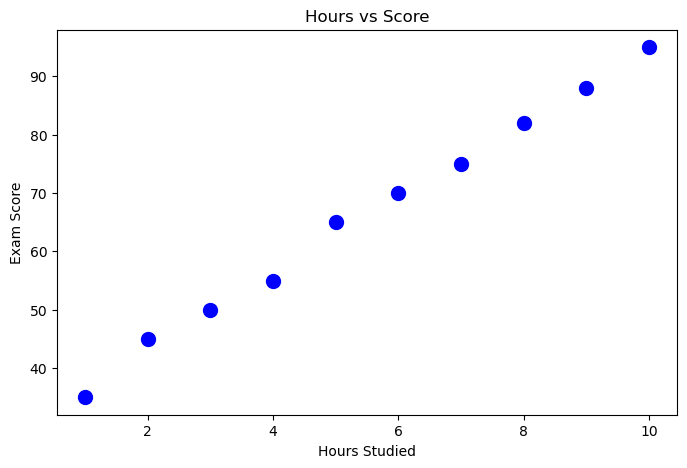

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(hours, scores, color='blue', s=100)
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Hours vs Score')
plt.savefig('scatter.png')
print("Chart saved")



In [5]:
print("Correlation:", round(np.corrcoef(hours, scores)[0][1], 3))

Correlation: 0.998


# Fit the Line 

In [6]:
from sklearn.linear_model import LinearRegression

In [7]:
X = hours.reshape(-1,1)

In [8]:
Y= scores

In [9]:
model = LinearRegression()

In [11]:
model.fit(X,Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
print("Slope (coefficient) :", round(model.coef_[0],3))

Slope (coefficient) : 6.461


In [14]:
print("Intercept:", round(model.intercept_, 3))
print("R² score:", round(model.score(X, Y), 3))

Intercept: 30.467
R² score: 0.996


Chart saved


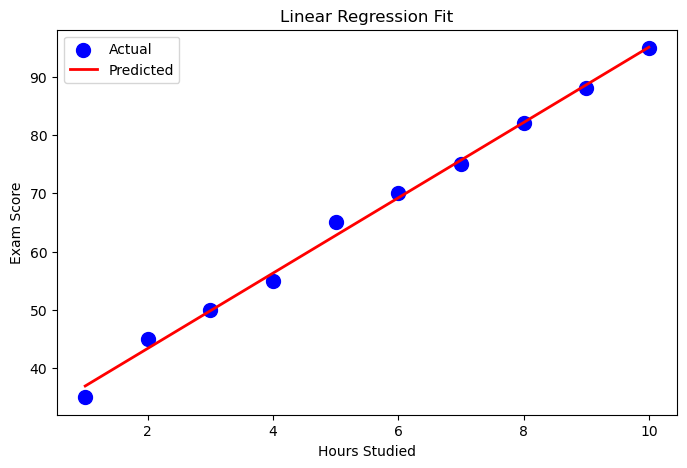

In [15]:
# Plot the line
plt.figure(figsize=(8, 5))
plt.scatter(hours, scores, color='blue', s=100, label='Actual')
plt.plot(hours, model.predict(X), color='red', 
         linewidth=2, label='Predicted')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend()
plt.title('Linear Regression Fit')
plt.savefig('linear_regression.png')
print("Chart saved")

# Make Prediction 

In [16]:
new_hours = np.array([3, 7, 11, 15]).reshape(-1, 1)
predictions = model.predict(new_hours)

for h, p in zip(new_hours.flatten(), predictions):
    print(f"Hours: {h} → Predicted score: {round(p, 1)}")

Hours: 3 → Predicted score: 49.8
Hours: 7 → Predicted score: 75.7
Hours: 11 → Predicted score: 101.5
Hours: 15 → Predicted score: 127.4


In [17]:
#  extrapolation — predicting outside the range of training data. The model was trained on hours 1-10. It has no idea what happens at 15 hours. It just extends the line blindly.

In [18]:
# Extrapolation warning:
# Model trained on hours 1-10
# Predicts 127.4 for 15 hours → impossible (max score = 100)
# Linear Regression assumes relationship continues forever
# Always check: are your predictions within realistic bounds?
# Production fix: add input validation
#   if hours > 10: "outside training range, prediction unreliable"

# R2 dive

In [19]:
y_pred  = model.predict(X)

In [20]:
y_mean = np.mean(scores)

In [24]:
# Total  variation in scores 

SS_Total =  np.sum((scores - y_mean)** 2)

In [25]:
# unexplained variation

SS_Residual = np.sum((scores - y_pred)** 2)

In [26]:
# R² = explained variation / total variation

r_squared = 1 - (SS_Residual/ SS_Total)

In [31]:
print("SS Total:", round(SS_Total, 2))
print("SS Residual:", round(SS_Residual, 2))
print("R² manual:", round(r_squared, 3))
print("R² sklearn:", round(model.score(X, Y), 3))
print("Match:", round(r_squared, 3) == round(model.score(X, Y), 3))

# Residuals
residuals = scores - y_pred
print("\nResiduals (actual - predicted):")
for h, r in zip(hours, residuals):
    print(f"Hours {h}: {round(r, 2)}")
    

SS Total: 3458.0
SS Residual: 14.5
R² manual: 0.996
R² sklearn: 0.996
Match: True

Residuals (actual - predicted):
Hours 1: -1.93
Hours 2: 1.61
Hours 3: 0.15
Hours 4: -1.31
Hours 5: 2.23
Hours 6: 0.77
Hours 7: -0.69
Hours 8: -0.15
Hours 9: -0.61
Hours 10: -0.07


Chart saved
Mean residual: 0.0
Std of residuals: 1.204


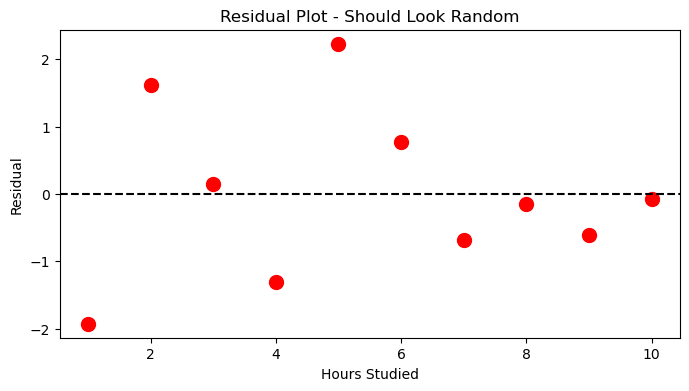

In [32]:
plt.figure(figsize=(8, 4))
plt.scatter(hours, residuals, color='red', s=100)
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Hours Studied')
plt.ylabel('Residual')
plt.title('Residual Plot - Should Look Random')
plt.savefig('residuals.png')
print("Chart saved")

# Check residual mean (should be near zero)
print("Mean residual:", round(np.mean(residuals), 6))
print("Std of residuals:", round(np.std(residuals), 3))

In [33]:
# Linear Regression finds weights that minimize
# the sum of squared residuals (MSE)

In [34]:
# Mean Squared  Error = average of squared residuals 

In [36]:
mse= np.mean(residuals ** 2)
rmse = np.sqrt(mse)

mae  = np.mean(np.abs(residuals))

In [37]:
print("MSE:", round(mse, 3))
print("RMSE:", round(rmse, 3))
print("MAE:", round(mae, 3))
print()
print("Interpretation:")
print(f"On average model is off by {round(rmse, 2)} points")
print(f"Worst single error: {round(max(abs(residuals)), 2)} points")

MSE: 1.45
RMSE: 1.204
MAE: 0.953

Interpretation:
On average model is off by 1.2 points
Worst single error: 2.23 points


In [38]:
# Linear Regression summary:
# Finds slope and intercept that minimize MSE
# R² = how much variation is explained (0-1)
# Residuals = actual - predicted (should be random)
# Mean residual = always exactly 0 (mathematical guarantee)
# RMSE = average error in same units as target
# MAE = more robust alternative to RMSE
#
# Extrapolation warning:
# Never trust predictions outside training data range
# Always add input validation in production